# Deepfake Audio Detection System

End-to-end KaggleHub workflow for training a compact CNN on the Fake-or-Real dataset. Run this notebook in Kaggle for full training so the dataset is attached through Kaggle's shared cache instead of consuming local disk. The current archive commonly stores the normalized training split under `for-norm/for-norm/training`.

In [1]:
!pip install -q kagglehub librosa soundfile torch matplotlib seaborn


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import kagglehub

path = kagglehub.dataset_download("mohammedabdeldayem/the-fake-or-real-dataset")
print("Path to dataset files:", path)

/Users/mamunchowdhury/Documents/Audio Detection/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/mamunchowdhury/.cache/kagglehub/datasets/mohammedabdeldayem/the-fake-or-real-dataset/versions/2


Upload or copy this repository into the Kaggle notebook, then set `PYTHONPATH` so the package imports resolve.

In [3]:
import os, sys

repo_src = "/Users/mamunchowdhury/Documents/Audio Detection/src"
os.environ["PYTHONPATH"] = repo_src + ":" + os.environ.get("PYTHONPATH", "")
if repo_src not in sys.path:
    sys.path.insert(0, repo_src)

In [4]:
from pathlib import Path
from audio_detection.data import build_manifest

dataset_root = Path("/Users/mamunchowdhury/.cache/kagglehub/datasets/mohammedabdeldayem/the-fake-or-real-dataset/versions/2/for-norm/for-norm/training")

manifest = build_manifest(dataset_root)

print(dataset_root)
print(f"Examples: {len(manifest)}")
print(f"Genuine: {sum(item.label == 0 for item in manifest)}")
print(f"Deepfake: {sum(item.label == 1 for item in manifest)}")

/Users/mamunchowdhury/.cache/kagglehub/datasets/mohammedabdeldayem/the-fake-or-real-dataset/versions/2/for-norm/for-norm/training
Examples: 53868
Genuine: 26941
Deepfake: 26927


In [5]:
from audio_detection.train import build_parser, train

args = build_parser().parse_args([
    "--data-root", "/Users/mamunchowdhury/.cache/kagglehub/datasets/mohammedabdeldayem/the-fake-or-real-dataset/versions/2/for-norm/for-norm/training",
    "--epochs", "3",
    "--batch-size", "16",
    "--sample-per-class", "200",
    "--model-dir", "models",
    "--reports-dir", "reports",
])

metrics = train(args)
metrics

Epoch 001 loss=0.5008 val_acc=0.8250 val_eer=0.1000 val_f1=0.8478
Epoch 002 loss=0.3906 val_acc=0.8875 val_eer=0.1000 val_f1=0.8800
Epoch 003 loss=0.3755 val_acc=0.8875 val_eer=0.1000 val_f1=0.8831


Matplotlib is building the font cache; this may take a moment.


Saved model to models/deepfake_cnn.pth
Saved metrics to reports/metrics.json


{'accuracy': 0.8875,
 'eer': 0.1,
 'f1': 0.8831168831168831,
 'per_class_accuracy': {'Genuine': 0.925, 'Deepfake': 0.85},
 'confusion_matrix': [[37, 3], [6, 34]],
 'threshold': 0.5}

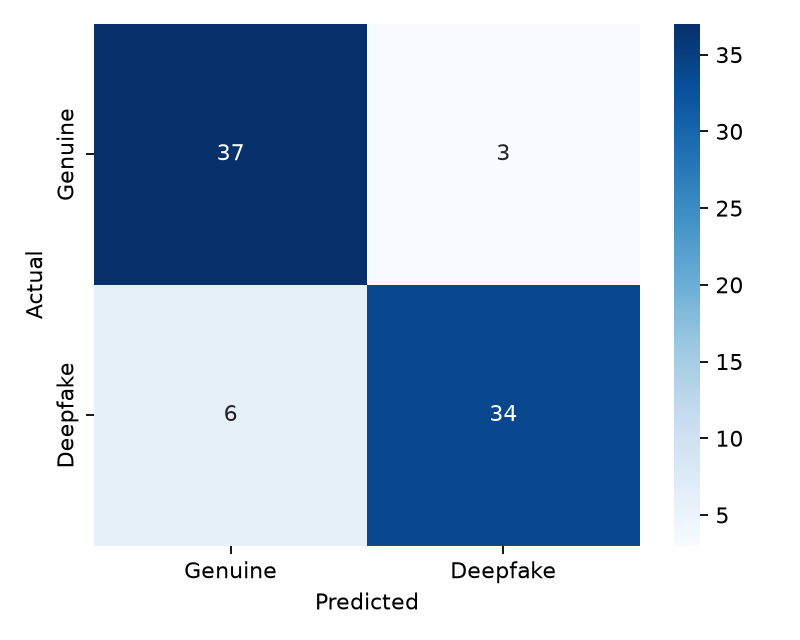

In [6]:
from IPython.display import Image, display
display(Image("reports/confusion_matrix.png"))

In [7]:
from audio_detection.train import build_parser, train

args = build_parser().parse_args([
    "--data-root", str(dataset_root),
    "--epochs", "30",
    "--batch-size", "32",
    "--model-dir", "models",
    "--reports-dir", "reports",
])

metrics = train(args)
metrics

Epoch 001 loss=0.2609 val_acc=0.9364 val_eer=0.0583 val_f1=0.9393
Epoch 002 loss=0.1559 val_acc=0.9631 val_eer=0.0288 val_f1=0.9623
Epoch 003 loss=0.1240 val_acc=0.9379 val_eer=0.0423 val_f1=0.9349
Epoch 004 loss=0.0987 val_acc=0.9672 val_eer=0.0169 val_f1=0.9682
Epoch 005 loss=0.0861 val_acc=0.9680 val_eer=0.0145 val_f1=0.9689
Epoch 006 loss=0.0760 val_acc=0.6013 val_eer=0.0473 val_f1=0.3367
Epoch 007 loss=0.0692 val_acc=0.9908 val_eer=0.0089 val_f1=0.9908
Epoch 008 loss=0.0607 val_acc=0.7130 val_eer=0.1069 val_f1=0.7769
Epoch 009 loss=0.0554 val_acc=0.8946 val_eer=0.0162 val_f1=0.9046
Epoch 010 loss=0.0516 val_acc=0.9684 val_eer=0.0065 val_f1=0.9694
Epoch 011 loss=0.0455 val_acc=0.9070 val_eer=0.0117 val_f1=0.9149
Epoch 012 loss=0.0425 val_acc=0.9936 val_eer=0.0045 val_f1=0.9936
Epoch 013 loss=0.0455 val_acc=0.9657 val_eer=0.0095 val_f1=0.9645
Epoch 014 loss=0.0392 val_acc=0.9757 val_eer=0.0080 val_f1=0.9762
Epoch 015 loss=0.0355 val_acc=0.9742 val_eer=0.0058 val_f1=0.9748
Epoch 016 

{'accuracy': 0.9029982363315696,
 'eer': 0.022834866710920585,
 'f1': 0.8926333093599097,
 'per_class_accuracy': {'Genuine': 0.9992576095025983,
  'Deepfake': 0.8066852367688022},
 'confusion_matrix': [[5384, 4], [1041, 4344]],
 'threshold': 0.5}

Download `models/deepfake_cnn.pth`, `models/model_config.json`, `reports/metrics.json`, and `reports/confusion_matrix.png` as final artifacts.

In [8]:
from pathlib import Path

for file in [
    "models/deepfake_cnn.pth",
    "models/model_config.json",
    "reports/metrics.json",
    "reports/confusion_matrix.png",
]:
    print(file, Path(file).resolve(), Path(file).exists())

models/deepfake_cnn.pth /Users/mamunchowdhury/Documents/Audio Detection/notebooks/models/deepfake_cnn.pth True
models/model_config.json /Users/mamunchowdhury/Documents/Audio Detection/notebooks/models/model_config.json True
reports/metrics.json /Users/mamunchowdhury/Documents/Audio Detection/notebooks/reports/metrics.json True
reports/confusion_matrix.png /Users/mamunchowdhury/Documents/Audio Detection/notebooks/reports/confusion_matrix.png True
